# TimesFM PCE Hybrid Forecasting Pipeline

## Phase 0 One-time environment setup (run in terminal, not here)

```powershell
# From G:\Coding\For Work\BUOD\Brent_simulation\TimesFM
python -m venv .venv
.venv\Scripts\Activate.ps1
pip install pandas matplotlib fredapi pytest pytest-cov ipykernel jupyter nbformat

# TimesFM installation (downloads ~500 MB from HuggingFace â€” do this once):
pip install timesfm[xreg]

# Register kernel
python -m ipykernel install --user --name=timesfm-env --display-name "Python (timesfm-env)"
```

After installation select kernel **"Python (timesfm-env)"** in the kernel picker above.


In [1]:
import sys
from pathlib import Path

# Make pipeline.py importable from the project root
PROJECT_ROOT = Path().resolve()
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from getpass import getpass
from pipeline import (
    parse_dreqrg_csv,
    fetch_brent_crude,
    merge_pce_brent,
    validate_scenarios,
    make_forecast_dates,
    build_history_payload,
    build_future_payload,
)

print("Pipeline module loaded OK")


Pipeline module loaded OK


## Phase 1 Data Acquisition

In [2]:
CSV_PATH = PROJECT_ROOT / "Section2All_xls - U20304-M.csv"
pce_df = parse_dreqrg_csv(CSV_PATH)
print(f"PCE series loaded: {len(pce_df)} months, "
      f"{pce_df['Date'].iloc[0].strftime('%Y-%m')} to "
      f"{pce_df['Date'].iloc[-1].strftime('%Y-%m')}")
display(pce_df.head(3))
display(pce_df.tail(3))


PCE series loaded: 806 months, 1959-01 to 2026-02


,Date,PCE_Index
0,1959-01-01,331.285
1,1959-02-01,331.295
2,1959-03-01,331.015


,Date,PCE_Index
803,2025-12-01,85.397
804,2026-01-01,86.730
805,2026-02-01,88.681


In [3]:
# Get a free API key at https://fred.stlouisfed.org/docs/api/api_key.html
FRED_API_KEY = "4840f2b6d06620ecc858b373a4669c43"
brent_df = fetch_brent_crude(FRED_API_KEY)
print(f"Brent Crude loaded: {len(brent_df)} months, "
      f"{brent_df['Date'].iloc[0].strftime('%Y-%m')} to "
      f"{brent_df['Date'].iloc[-1].strftime('%Y-%m')}")
display(brent_df.tail(3))


Brent Crude loaded: 468 months, 1987-05 to 2026-04


,Date,Brent_Crude
465,2026-02-01,71.32
466,2026-03-01,126.69
467,2026-04-01,113.89


Merged dataset: 466 months, 1987-05 to 2026-02


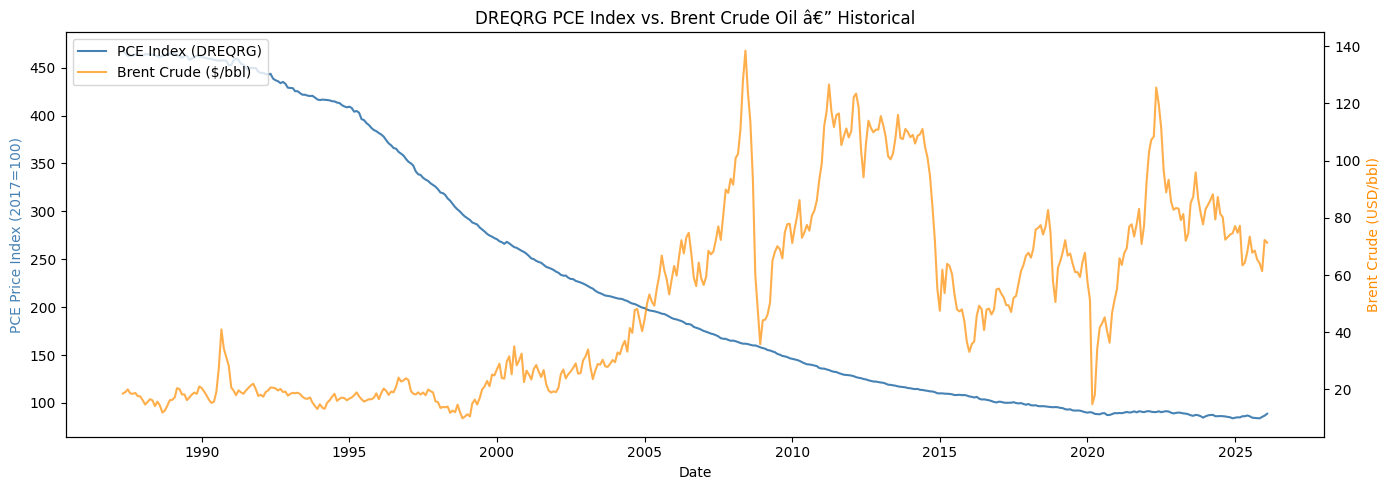

In [4]:
merged_df = merge_pce_brent(pce_df, brent_df)
print(f"Merged dataset: {len(merged_df)} months, "
      f"{merged_df['Date'].iloc[0].strftime('%Y-%m')} to "
      f"{merged_df['Date'].iloc[-1].strftime('%Y-%m')}")

fig, ax1 = plt.subplots(figsize=(14, 5))
ax2 = ax1.twinx()

ax1.plot(merged_df["Date"], merged_df["PCE_Index"], color="steelblue", label="PCE Index (DREQRG)")
ax2.plot(merged_df["Date"], merged_df["Brent_Crude"], color="darkorange", alpha=0.7, label="Brent Crude ($/bbl)")

ax1.set_ylabel("PCE Price Index (2017=100)", color="steelblue")
ax2.set_ylabel("Brent Crude (USD/bbl)", color="darkorange")
ax1.set_xlabel("Date")
ax1.set_title("DREQRG PCE Index vs. Brent Crude Oil â€” Historical")
ax1.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
ax1.xaxis.set_major_locator(mdates.YearLocator(5))

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc="upper left")

plt.tight_layout()
plt.show()


## Phase 2 Qualitative Scenario Generation (Gemini)

**Copy the prompt below, paste it into [gemini.google.com](https://gemini.google.com), then paste the output into Cell 6.**

---

> **PROMPT TO PASTE INTO GEMINI:**
>
> You are a macroeconomic analyst specializing in energy markets and consumer spending. Your task is to generate three 13-month forward trajectories for Brent Crude oil prices (May 2026 through May 2027 inclusive), calibrated against specific historical macro regimes.
>
> **Historical Regime Context (for elasticity calibration):**
> - **2007 - 2008 (Demand Shock):** Brent peaked >$140/bbl in a booming global economy, then collapsed with the GFC. Tech spending was high until the credit freeze caused sudden demand destruction. Elasticity pattern: gradual rise â†’ sharp peak â†’ collapse.
> - **2010 - 2011 (Arab Spring / Supply Shock):** Brent spiked past $120/bbl due to Middle East instability + Tohoku earthquake crippling semiconductor/photographic supply chains. Price increases driven by product scarcity, not just energy. Elasticity pattern: step-up plateau with elevated volatility.
> - **2021 - 2022 (Post-Pandemic / Ukraine War):** Oil spiked amid Russia-Ukraine conflict and global reopening. Energy acted as a multiplier on existing supply chain paralysis and chip shortages. Elasticity pattern: persistent elevated baseline with a single sharp spike.
>
> **Your Task:**
> 1. Briefly assess the current geopolitical and macroeconomic landscape as of May 2026 (include: active conflicts, OPEC+ posture, global growth trajectory, any major supply chain disruptions).
> 2. Identify which historical regime (or blend) best maps to today's reality. Justify in 2-3 sentences.
> 3. Generate exactly **three named scenarios** as Python lists of 13 monthly Brent Crude price values (USD/bbl), covering May 2026 through May 2027:
>    - `base_case`: Highest-probability path based on current consensus and the matched historical elasticity.
>    - `bull_case`: Severe upside shock (e.g., rapid conflict escalation, major supply disruption).
>    - `bear_case`: Downside scenario (e.g., global recession signal, unexpected supply glut, OPEC+ collapse).
>
> **Output format return exactly this Python block:**
> ```python
> base_case = [X, X, X, X, X, X, X, X, X, X, X, X, X]   # May 2026 â€“ May 2027
> bull_case = [X, X, X, X, X, X, X, X, X, X, X, X, X]
> bear_case = [X, X, X, X, X, X, X, X, X, X, X, X, X]
> narrative = """
> [2-3 sentence justification of the analog match and key assumptions]
> """
> ```


In [5]:
base_case = [118.0, 121.0, 119.0, 122.0, 118.0, 115.0, 117.0, 114.0, 112.0, 110.0, 111.0, 108.0, 105.0]   # May 2026 – May 2027
bull_case = [120.0, 135.0, 145.0, 150.0, 148.0, 142.0, 145.0, 138.0, 135.0, 140.0, 138.0, 135.0, 130.0]
bear_case = [115.0, 95.0, 85.0, 80.0, 78.0, 75.0, 70.0, 68.0, 65.0, 65.0, 62.0, 60.0, 58.0]
narrative = """
As of May 2026, energy markets are reeling from the U.S.-Israel-Iran conflict and the resulting closure of the Strait of Hormuz (pushing Brent near $118/bbl), coupled with the UAE's sudden May 1 exit from OPEC+ to monetize its massive spare capacity. This landscape best maps to the 2010–2011 Arab Spring supply shock regime, which was characterized by a step-up plateau and elevated volatility. The physical product scarcity created by the Hormuz blockade establishes a persistently high structural baseline, while the threat of an unrestrained UAE flooding the market once shipping lanes reopen injects immense forward-looking volatility.
"""

forecast_dates = make_forecast_dates()
validate_scenarios(base_case, bull_case, bear_case)

print("Scenarios validated OK")
print(f"Forecast window: {forecast_dates[0].strftime('%Y-%m')} to {forecast_dates[-1].strftime('%Y-%m')}")
print("Narrative:", narrative.strip())
print("Base Case ($/bbl):", base_case)


Scenarios validated OK
Forecast window: 2026-05 to 2027-05
Narrative: As of May 2026, energy markets are reeling from the U.S.-Israel-Iran conflict and the resulting closure of the Strait of Hormuz (pushing Brent near $118/bbl), coupled with the UAE's sudden May 1 exit from OPEC+ to monetize its massive spare capacity. This landscape best maps to the 2010–2011 Arab Spring supply shock regime, which was characterized by a step-up plateau and elevated volatility. The physical product scarcity created by the Hormuz blockade establishes a persistently high structural baseline, while the threat of an unrestrained UAE flooding the market once shipping lanes reopen injects immense forward-looking volatility.
Base Case ($/bbl): [118.0, 121.0, 119.0, 122.0, 118.0, 115.0, 117.0, 114.0, 112.0, 110.0, 111.0, 108.0, 105.0]


## Phase 3 TimesFM Quantitative Forecasting

In [6]:
import timesfm

# TimesFM 2.5 API: from_pretrained() replaces TimesFm/TimesFmHparams/TimesFmCheckpoint.
# First run downloads ~500 MB from HuggingFace — subsequent runs use local cache.
# return_backcast=True is required to use forecast_with_covariates.
tfm = timesfm.TimesFM_2p5_200M_torch.from_pretrained(
    "google/timesfm-2.5-200m-pytorch"
)
tfm.compile(
    timesfm.ForecastConfig(
        max_context=1024,
        max_horizon=256,
        normalize_inputs=True,
        return_backcast=True,
    )
)
print("TimesFM model initialized and compiled")


config.json:   0%|          | 0.00/475 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/925M [00:00<?, ?B/s]

TimesFM model initialized and compiled


In [7]:
import numpy as np

scenarios = {
    "base": base_case,
    "bull": bull_case,
    "bear": bear_case,
}
forecasts = {}

for name, scenario in scenarios.items():
    history_df = build_history_payload(merged_df, context_len=120)

    # TimesFM 2.5 takes numpy arrays, not DataFrames.
    pce_context = history_df["y"].to_numpy()               # shape: (120,)
    brent_context = history_df["Brent_Crude"].to_numpy()   # shape: (120,)
    brent_future = np.array(scenario, dtype=float)          # shape: (13,)

    # Dynamic covariate must cover context + horizon.
    # Horizon is inferred as len(combined) - len(input) = 133 - 120 = 13.
    brent_combined = np.concatenate([brent_context, brent_future])  # shape: (133,)

    point_fc, _ = tfm.forecast_with_covariates(
        inputs=[pce_context],
        dynamic_numerical_covariates={"Brent_Crude": [brent_combined]},
        xreg_mode="xreg + timesfm",
        normalize_xreg_target_per_input=True,
    )
    # point_fc shape: (1, horizon) — slice to 13 steps
    forecasts[name] = point_fc[0][:13]
    print(f"{name}: {forecasts[name]}")

print("All forecasts complete. NaN check:",
      {k: int(pd.isna(v).sum()) for k, v in forecasts.items()})


base: [84.13944725 84.61641733 85.45015565 85.53279797 86.29946302 87.40745441
 87.78823006 88.5271013  89.15588139 89.34963368 89.31804754 89.97482265
 90.16282517]
bull: [83.91000882 83.01034555 82.46745121 82.32065441 82.85788137 84.31003109
 84.57608786 85.77383632 86.51733511 85.90805135 86.22062439 86.87739883
 87.29484028]
bear: [84.48360525 87.59912143 89.35061486 90.35101263 90.88823924 91.99623028
 93.180042   93.80419351 94.54769299 94.5120065  94.93929825 95.48135381
 95.55463659]
All forecasts complete. NaN check: {'base': 0, 'bull': 0, 'bear': 0}


## Phase 4 Visualization

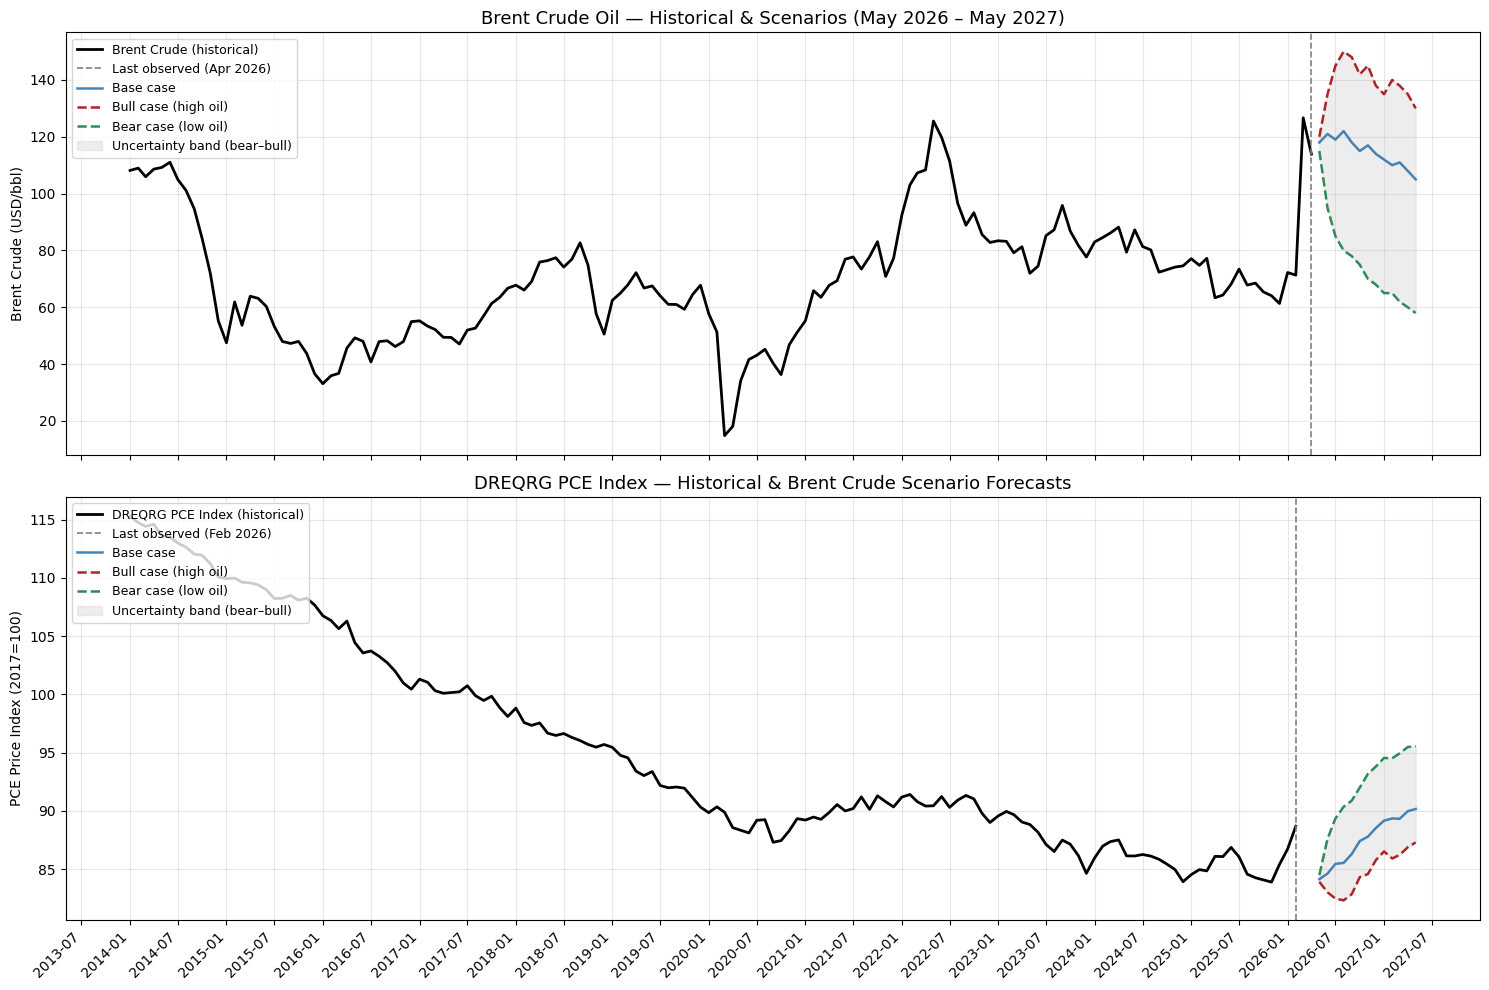

Chart saved to dreqrg_forecast_fan_chart.png


In [8]:
# Historical window: last 12 years for readability
history_start = pd.Timestamp("2014-01-01")

brent_hist = brent_df[brent_df["Date"] >= history_start]
pce_hist   = pce_df[pce_df["Date"] >= history_start]
last_brent_obs = pd.Timestamp("2026-04-01")
last_pce_obs   = pd.Timestamp("2026-02-01")

scenario_styles = {
    "base": ("steelblue",  "-",  "Base case"),
    "bull": ("firebrick",  "--", "Bull case (high oil)"),
    "bear": ("seagreen",   "--", "Bear case (low oil)"),
}
brent_scenarios = {"base": base_case, "bull": bull_case, "bear": bear_case}

fig, (ax_brent, ax_pce) = plt.subplots(2, 1, figsize=(15, 10), sharex=True)

# ── Top panel: Brent Crude ───────────────────────────────────────────
ax_brent.plot(brent_hist["Date"], brent_hist["Brent_Crude"],
              color="black", linewidth=2, label="Brent Crude (historical)")
ax_brent.axvline(last_brent_obs, color="gray", linestyle="--", linewidth=1.2,
                 label="Last observed (Apr 2026)")
for name, (color, ls, label) in scenario_styles.items():
    ax_brent.plot(forecast_dates, brent_scenarios[name],
                  color=color, linewidth=1.8, linestyle=ls, label=label)
ax_brent.fill_between(forecast_dates,
                      brent_scenarios["bear"], brent_scenarios["bull"],
                      color="lightgray", alpha=0.4, label="Uncertainty band (bear–bull)")
ax_brent.set_ylabel("Brent Crude (USD/bbl)")
ax_brent.set_title("Brent Crude Oil — Historical & Scenarios (May 2026 – May 2027)", fontsize=13)
ax_brent.legend(loc="upper left", fontsize=9)
ax_brent.grid(True, alpha=0.3)

# ── Bottom panel: PCE Index ──────────────────────────────────────────
ax_pce.plot(pce_hist["Date"], pce_hist["PCE_Index"],
            color="black", linewidth=2, label="DREQRG PCE Index (historical)")
ax_pce.axvline(last_pce_obs, color="gray", linestyle="--", linewidth=1.2,
               label="Last observed (Feb 2026)")
for name, (color, ls, label) in scenario_styles.items():
    ax_pce.plot(forecast_dates, forecasts[name],
                color=color, linewidth=1.8, linestyle=ls, label=label)
ax_pce.fill_between(forecast_dates,
                    forecasts["bear"], forecasts["bull"],
                    color="lightgray", alpha=0.4, label="Uncertainty band (bear–bull)")
ax_pce.set_ylabel("PCE Price Index (2017=100)")
ax_pce.set_title("DREQRG PCE Index — Historical & Brent Crude Scenario Forecasts", fontsize=13)
ax_pce.legend(loc="upper left", fontsize=9)
ax_pce.grid(True, alpha=0.3)

# ── Shared x-axis ────────────────────────────────────────────────────
ax_pce.xaxis.set_major_formatter(mdates.DateFormatter("%Y-%m"))
ax_pce.xaxis.set_major_locator(mdates.MonthLocator(bymonth=[1, 7]))
plt.setp(ax_pce.xaxis.get_majorticklabels(), rotation=45, ha="right")

plt.tight_layout()
plt.savefig("dreqrg_forecast_fan_chart.png", dpi=150)
plt.show()
print("Chart saved to dreqrg_forecast_fan_chart.png")
